# LSTM from Scratch: Understanding Gates and Memory

In this notebook, we'll build a **Long Short-Term Memory (LSTM)** network from the ground up, developing deep intuitions about how LSTMs solve the vanishing gradient problem through gating mechanisms.

## What we'll learn:
- Why RNNs struggle with long sequences (vanishing gradients)
- How LSTM gates control information flow
- The difference between cell state and hidden state
- Implementing an LSTM cell from scratch
- Visualizing gate activations during training
- Training on a name generation task

## Learning approach:
We'll build understanding incrementally:
1. **Problem**: Why we need LSTMs
2. **Solution**: Gate mechanisms
3. **Implementation**: Build each component
4. **Visualization**: See gates in action
5. **Application**: Character-level language modeling

## 1. Setup

Import necessary libraries and configure the environment.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from aiml_notebooks import (
    create_dataset,
    create_dataloaders,
    get_device,
    set_seed,
    count_parameters
)

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility and configure device.

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. The Problem: Vanishing Gradients in RNNs

### Why do we need LSTMs?

Standard RNNs have a simple recurrence: $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$

The **vanishing gradient problem** occurs when:
- Gradients are backpropagated through many time steps
- Each step multiplies by the weight matrix
- If eigenvalues < 1, gradients exponentially decay

This means **RNNs struggle to learn long-term dependencies**.

Let's demonstrate this with a simple gradient flow experiment.

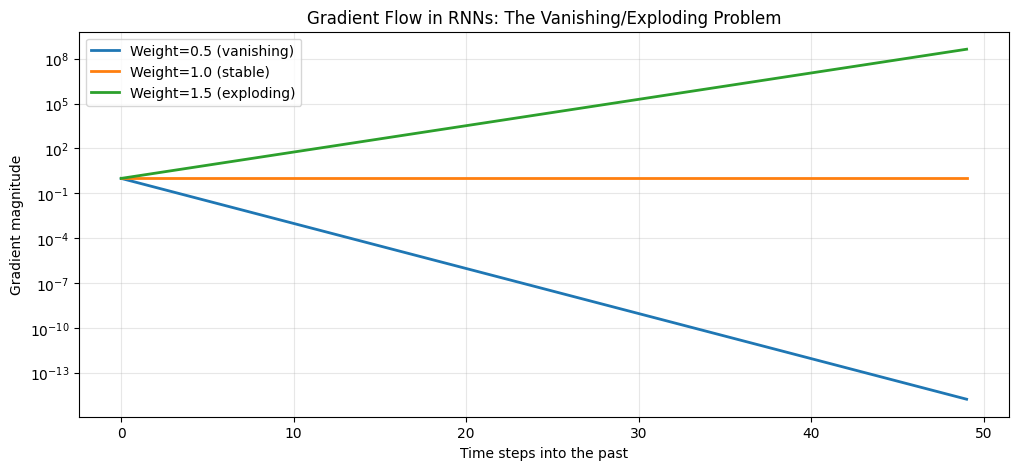

In [3]:
def compute_gradient_magnitudes(sequence_length, weight_value=0.5):
    """
    Simulate gradient flow through time in a simple RNN.
    Returns gradient magnitudes at each time step.
    """
    # Simulate gradient = (weight^t) for each step t
    gradients = [weight_value ** t for t in range(sequence_length)]
    return gradients

# Compute for different sequence lengths
seq_len = 50
grad_small_weight = compute_gradient_magnitudes(seq_len, weight_value=0.5)
grad_unit_weight = compute_gradient_magnitudes(seq_len, weight_value=1.0)
grad_large_weight = compute_gradient_magnitudes(seq_len, weight_value=1.5)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(grad_small_weight, label='Weight=0.5 (vanishing)', linewidth=2)
plt.plot(grad_unit_weight, label='Weight=1.0 (stable)', linewidth=2)
plt.plot(grad_large_weight, label='Weight=1.5 (exploding)', linewidth=2)
plt.xlabel('Time steps into the past')
plt.ylabel('Gradient magnitude')
plt.title('Gradient Flow in RNNs: The Vanishing/Exploding Problem')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

**Key insight**: With typical weight values (< 1), gradients decay exponentially. After 20-30 steps, they're essentially zero!

This is why RNNs can't learn dependencies spanning more than ~10 time steps.

## 3. The Solution: LSTM Architecture

### Core Idea: Gated Information Flow

LSTMs solve vanishing gradients through:
1. **Cell state** ($c_t$): A "memory highway" that flows through time with minimal transformations
2. **Gates**: Learned mechanisms to control information flow

Three gates control the cell state:
- **Forget gate** ($f_t$): What to remove from memory
- **Input gate** ($i_t$): What new information to add
- **Output gate** ($o_t$): What to output from memory

Let's visualize the LSTM architecture conceptually.

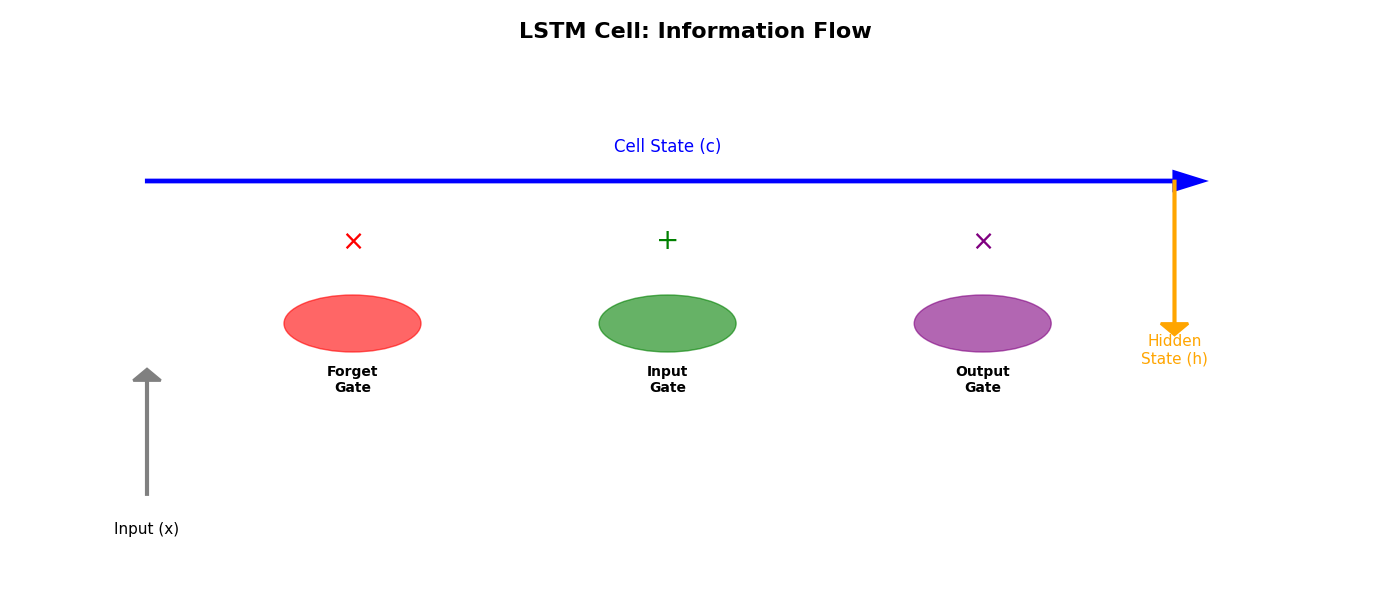

In [4]:
# Create a simple diagram showing LSTM information flow
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Title
ax.text(0.5, 0.95, 'LSTM Cell: Information Flow', 
        ha='center', fontsize=16, fontweight='bold')

# Cell state flow (top horizontal line)
ax.arrow(0.1, 0.7, 0.75, 0, head_width=0.03, head_length=0.02, 
         fc='blue', ec='blue', linewidth=3)
ax.text(0.48, 0.75, 'Cell State (c)', ha='center', fontsize=12, color='blue')

# Gates
gate_y = 0.45
gate_positions = [0.25, 0.48, 0.71]
gate_names = ['Forget\nGate', 'Input\nGate', 'Output\nGate']
gate_colors = ['red', 'green', 'purple']

for pos, name, color in zip(gate_positions, gate_names, gate_colors):
    circle = plt.Circle((pos, gate_y), 0.05, color=color, alpha=0.6)
    ax.add_patch(circle)
    ax.text(pos, gate_y-0.12, name, ha='center', fontsize=10, fontweight='bold')

# Input/Output flows
ax.arrow(0.1, 0.15, 0, 0.2, head_width=0.02, head_length=0.02, 
         fc='gray', ec='gray', linewidth=2)
ax.text(0.1, 0.08, 'Input (x)', ha='center', fontsize=11)

ax.arrow(0.85, 0.7, 0, -0.25, head_width=0.02, head_length=0.02, 
         fc='orange', ec='orange', linewidth=2)
ax.text(0.85, 0.38, 'Hidden\nState (h)', ha='center', fontsize=11, color='orange')

# Annotations
ax.text(0.25, 0.58, '×', ha='center', fontsize=20, color='red')
ax.text(0.48, 0.58, '+', ha='center', fontsize=20, color='green')
ax.text(0.71, 0.58, '×', ha='center', fontsize=20, color='purple')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Key insight**: The cell state flows almost unchanged through time. Gates only **add** or **multiply** — allowing gradients to flow back effectively!

## 4. LSTM Mathematics: Step by Step

### The Complete LSTM Equations

Given input $x_t$, previous hidden state $h_{t-1}$, and previous cell state $c_{t-1}$:

**Forget Gate** (what to forget from cell state):
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**Input Gate** (what new information to add):
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$

**Cell State Update**:
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

**Output Gate** (what to output):
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

Where:
- $\sigma$ is sigmoid (outputs 0-1, acts as gate)
- $\odot$ is element-wise multiplication
- $\tanh$ squashes values to [-1, 1]

## 5. Implementation: Building an LSTM Cell

### Step 1: Understand Tensor Shapes

Before implementing, let's clarify the tensor dimensions we'll work with.

In [5]:
# Example dimensions
batch_size = 32
input_size = 10   # embedding dimension
hidden_size = 20  # LSTM hidden state size

# Create dummy tensors
x_t = torch.randn(batch_size, input_size)        # Current input
h_prev = torch.randn(batch_size, hidden_size)    # Previous hidden state
c_prev = torch.randn(batch_size, hidden_size)    # Previous cell state

print(f"Input x_t:           {x_t.shape}")
print(f"Hidden state h_t-1:  {h_prev.shape}")
print(f"Cell state c_t-1:    {c_prev.shape}")
print(f"\nConcatenated [h, x]: {torch.cat([h_prev, x_t], dim=1).shape}")

Input x_t:           torch.Size([32, 10])
Hidden state h_t-1:  torch.Size([32, 20])
Cell state c_t-1:    torch.Size([32, 20])

Concatenated [h, x]: torch.Size([32, 30])


**Key insight**: We concatenate $h_{t-1}$ and $x_t$ to form a single input to each gate.

### Step 2: Implement the Forget Gate

The forget gate decides what information to discard from the cell state.

In [6]:
class ForgetGate(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Linear transformation for [h_t-1, x_t] -> forget values
        self.linear = nn.Linear(hidden_size + input_size, hidden_size)
    
    def forward(self, h_prev, x_t):
        # Concatenate hidden and input
        combined = torch.cat([h_prev, x_t], dim=1)
        # Sigmoid outputs values between 0 (forget) and 1 (keep)
        f_t = torch.sigmoid(self.linear(combined))
        return f_t

# Test it
forget_gate = ForgetGate(input_size, hidden_size)
f_t = forget_gate(h_prev, x_t)

print(f"Forget gate output shape: {f_t.shape}")
print(f"Forget gate values (sample): {f_t[0, :5]}")
print(f"Range: [{f_t.min():.3f}, {f_t.max():.3f}]")

Forget gate output shape: torch.Size([32, 20])
Forget gate values (sample): tensor([0.4818, 0.5824, 0.4551, 0.5840, 0.3584], grad_fn=<SliceBackward0>)
Range: [0.076, 0.845]


**Key insight**: Values near 0 mean "forget this information", values near 1 mean "keep it".

### Step 3: Implement the Input Gate

The input gate decides what new information to add to the cell state.

In [7]:
class InputGate(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Gate values (what to update)
        self.linear_i = nn.Linear(hidden_size + input_size, hidden_size)
        # Candidate values (what new information to add)
        self.linear_c = nn.Linear(hidden_size + input_size, hidden_size)
    
    def forward(self, h_prev, x_t):
        combined = torch.cat([h_prev, x_t], dim=1)
        # Gate: what to update (0-1)
        i_t = torch.sigmoid(self.linear_i(combined))
        # Candidate: new information (-1 to 1)
        c_tilde = torch.tanh(self.linear_c(combined))
        return i_t, c_tilde

# Test it
input_gate = InputGate(input_size, hidden_size)
i_t, c_tilde = input_gate(h_prev, x_t)

print(f"Input gate (i_t) shape: {i_t.shape}")
print(f"Candidate (c̃_t) shape: {c_tilde.shape}")
print(f"\nInput gate range: [{i_t.min():.3f}, {i_t.max():.3f}]")
print(f"Candidate range: [{c_tilde.min():.3f}, {c_tilde.max():.3f}]")

Input gate (i_t) shape: torch.Size([32, 20])
Candidate (c̃_t) shape: torch.Size([32, 20])

Input gate range: [0.178, 0.853]
Candidate range: [-0.956, 0.916]


**Key insight**: The input gate has TWO components:
- $i_t$: How much to use the new information (0-1)
- $\tilde{c}_t$: What the new information is (-1 to 1)

### Step 4: Update the Cell State

Now we combine forget and input gates to update the cell state.

New cell state shape: torch.Size([32, 20])
Cell state range: [-2.702, 2.124]


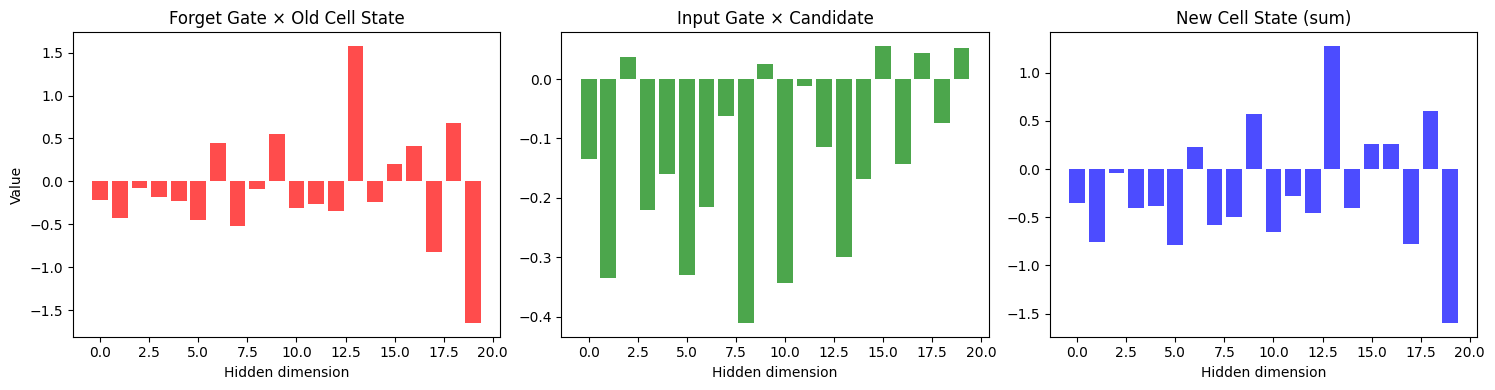

In [8]:
# Compute new cell state
# c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t
c_t = f_t * c_prev + i_t * c_tilde

print(f"New cell state shape: {c_t.shape}")
print(f"Cell state range: [{c_t.min():.3f}, {c_t.max():.3f}]")

# Visualize the update
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot first sample's values
idx = 0
axes[0].bar(range(hidden_size), (f_t * c_prev)[idx].detach().numpy(), alpha=0.7, color='red')
axes[0].set_title('Forget Gate × Old Cell State')
axes[0].set_xlabel('Hidden dimension')
axes[0].set_ylabel('Value')

axes[1].bar(range(hidden_size), (i_t * c_tilde)[idx].detach().numpy(), alpha=0.7, color='green')
axes[1].set_title('Input Gate × Candidate')
axes[1].set_xlabel('Hidden dimension')

axes[2].bar(range(hidden_size), c_t[idx].detach().numpy(), alpha=0.7, color='blue')
axes[2].set_title('New Cell State (sum)')
axes[2].set_xlabel('Hidden dimension')

plt.tight_layout()
plt.show()

**Key insight**: Cell state is a weighted sum of:
- Old memory (filtered by forget gate)
- New memory (filtered by input gate)

This is why gradients flow well — it's just addition and multiplication!

### Step 5: Implement the Output Gate

The output gate controls what information from the cell state becomes the hidden state output.

In [9]:
class OutputGate(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size + input_size, hidden_size)
    
    def forward(self, h_prev, x_t, c_t):
        combined = torch.cat([h_prev, x_t], dim=1)
        # Gate: what to output (0-1)
        o_t = torch.sigmoid(self.linear(combined))
        # Hidden state: filtered cell state
        h_t = o_t * torch.tanh(c_t)
        return h_t, o_t

# Test it
output_gate = OutputGate(input_size, hidden_size)
h_t, o_t = output_gate(h_prev, x_t, c_t)

print(f"Output gate (o_t) shape: {o_t.shape}")
print(f"Hidden state (h_t) shape: {h_t.shape}")
print(f"\nOutput gate range: [{o_t.min():.3f}, {o_t.max():.3f}]")
print(f"Hidden state range: [{h_t.min():.3f}, {h_t.max():.3f}]")

Output gate (o_t) shape: torch.Size([32, 20])
Hidden state (h_t) shape: torch.Size([32, 20])

Output gate range: [0.107, 0.832]
Hidden state range: [-0.707, 0.646]


**Key insight**: The output gate decides what parts of the cell state (our long-term memory) to expose as the hidden state (our short-term output).

### Step 6: Complete LSTM Cell

Now let's combine everything into a single LSTM cell.

In [10]:
class LSTMCell(nn.Module):
    """A single LSTM cell that processes one time step."""
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Combined weights for all gates (more efficient than separate)
        # Order: input, forget, cell, output (i, f, c, o)
        self.weight_ih = nn.Linear(input_size, 4 * hidden_size)
        self.weight_hh = nn.Linear(hidden_size, 4 * hidden_size)
    
    def forward(self, x_t, h_prev, c_prev):
        """
        Args:
            x_t: (batch, input_size) - current input
            h_prev: (batch, hidden_size) - previous hidden state
            c_prev: (batch, hidden_size) - previous cell state
        
        Returns:
            h_t: (batch, hidden_size) - new hidden state
            c_t: (batch, hidden_size) - new cell state
            gates: dict with gate activations for visualization
        """
        # Compute all gates in one go (efficient!)
        gates_x = self.weight_ih(x_t)      # from input
        gates_h = self.weight_hh(h_prev)   # from hidden
        gates = gates_x + gates_h          # combine
        
        # Split into 4 gates
        i_t, f_t, c_tilde, o_t = gates.chunk(4, dim=1)
        
        # Apply activations
        i_t = torch.sigmoid(i_t)       # input gate
        f_t = torch.sigmoid(f_t)       # forget gate
        c_tilde = torch.tanh(c_tilde)  # candidate cell state
        o_t = torch.sigmoid(o_t)       # output gate
        
        # Update cell state
        c_t = f_t * c_prev + i_t * c_tilde
        
        # Update hidden state
        h_t = o_t * torch.tanh(c_t)
        
        # Return states and gates (for visualization)
        gate_activations = {
            'forget': f_t,
            'input': i_t,
            'output': o_t,
            'candidate': c_tilde
        }
        
        return h_t, c_t, gate_activations

# Test the complete cell
lstm_cell = LSTMCell(input_size, hidden_size)
h_new, c_new, gates = lstm_cell(x_t, h_prev, c_prev)

print(f"LSTM Cell created!")
print(f"Parameters: {count_parameters(lstm_cell):,}")
print(f"\nOutput shapes:")
print(f"  h_t: {h_new.shape}")
print(f"  c_t: {c_new.shape}")
print(f"\nGate activations available: {list(gates.keys())}")

LSTM Cell created!
Parameters: 2,560

Output shapes:
  h_t: torch.Size([32, 20])
  c_t: torch.Size([32, 20])

Gate activations available: ['forget', 'input', 'output', 'candidate']


**Key insight**: All gates are computed in parallel for efficiency. The cell returns gate activations so we can visualize what the LSTM is learning!

## 6. Building a Complete LSTM Network

### LSTM for Sequence Processing

Now we'll build a full LSTM that processes sequences by applying the LSTM cell to each time step.

In [11]:
class LSTM(nn.Module):
    """Complete LSTM for sequence processing."""
    
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Stack of LSTM cells
        self.cells = nn.ModuleList([
            LSTMCell(
                input_size if i == 0 else hidden_size,
                hidden_size
            )
            for i in range(num_layers)
        ])
    
    def forward(self, x, hidden=None, return_gates=False):
        """
        Args:
            x: (batch, seq_len, input_size)
            hidden: tuple of (h_0, c_0) or None
            return_gates: whether to return gate activations
        
        Returns:
            output: (batch, seq_len, hidden_size)
            (h_n, c_n): final hidden and cell states
            gates: (optional) list of gate activations per timestep
        """
        batch_size, seq_len, _ = x.size()
        
        # Initialize hidden states if not provided
        if hidden is None:
            h = [torch.zeros(batch_size, self.hidden_size, device=x.device)
                 for _ in range(self.num_layers)]
            c = [torch.zeros(batch_size, self.hidden_size, device=x.device)
                 for _ in range(self.num_layers)]
        else:
            h, c = hidden
            h = list(h)
            c = list(c)
        
        # Process sequence
        outputs = []
        all_gates = [] if return_gates else None
        
        for t in range(seq_len):
            x_t = x[:, t, :]  # (batch, input_size)
            
            # Process through layers
            layer_gates = []
            for layer in range(self.num_layers):
                h[layer], c[layer], gates = self.cells[layer](
                    x_t, h[layer], c[layer]
                )
                x_t = h[layer]  # output becomes input to next layer
                if return_gates:
                    layer_gates.append(gates)
            
            outputs.append(h[-1])  # collect top layer output
            if return_gates:
                all_gates.append(layer_gates)
        
        # Stack outputs
        output = torch.stack(outputs, dim=1)  # (batch, seq_len, hidden_size)
        
        # Stack final states
        h_n = torch.stack(h, dim=0)  # (num_layers, batch, hidden_size)
        c_n = torch.stack(c, dim=0)
        
        if return_gates:
            return output, (h_n, c_n), all_gates
        return output, (h_n, c_n)

# Test the LSTM
seq_len = 10
test_input = torch.randn(batch_size, seq_len, input_size)

lstm = LSTM(input_size, hidden_size, num_layers=2)
output, (h_final, c_final) = lstm(test_input)

print(f"LSTM Network created!")
print(f"Parameters: {count_parameters(lstm):,}")
print(f"\nInput shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Final hidden state shape: {h_final.shape}")
print(f"Final cell state shape: {c_final.shape}")

LSTM Network created!
Parameters: 5,920

Input shape: torch.Size([32, 10, 10])
Output shape: torch.Size([32, 10, 20])
Final hidden state shape: torch.Size([2, 32, 20])
Final cell state shape: torch.Size([2, 32, 20])


**Key insight**: The LSTM processes sequences step-by-step, maintaining hidden and cell states throughout. Multiple layers can be stacked for more capacity.

## 7. Preparing Data for Training

### Load the Names Dataset

We'll train on the same character-level language modeling task as before.

In [12]:
# Load dataset
full_dataset, train_dataset, val_dataset = create_dataset(
    "names", 
    splits=[0.9, 0.1]
)

tokenizer = full_dataset.tokenizer
vocab_size = tokenizer.vocab_size

print(f"Dataset loaded!")
print(f"Vocabulary: {tokenizer.chars}")
print(f"Vocabulary size: {vocab_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Show examples
print(f"\nSample names:")
for name in full_dataset.get_texts()[:5]:
    print(f"  {name}")

Dataset loaded!
Vocabulary: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Vocabulary size: 27
Training samples: 28829
Validation samples: 3204

Sample names:
  emma
  olivia
  ava
  isabella
  sophia


Create dataloaders for batch training.

In [13]:
batch_size = 128

train_loader, val_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=batch_size
)

print(f"Dataloaders created!")
print(f"Batches per epoch: {len(train_loader)}")

# Examine a batch
x_batch, y_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Input (x):  {x_batch.shape}  # (batch, seq_len)")
print(f"  Target (y): {y_batch.shape}  # (batch, seq_len)")

# Show example
idx = 0
print(f"\nExample sequence:")
x_tokens = x_batch[idx].tolist()
y_tokens = [t for t in y_batch[idx].tolist() if t != -100]  # Filter padding
print(f"  Input:  {tokenizer.decode(x_tokens)}")
print(f"  Target: {tokenizer.decode(y_tokens)}")

Dataloaders created!
Batches per epoch: 226

Batch shapes:
  Input (x):  torch.Size([128, 11])  # (batch, seq_len)
  Target (y): torch.Size([128, 11])  # (batch, seq_len)

Example sequence:
  Input:  .jeffery...
  Target: jeffery.


## 8. Character-Level Language Model with LSTM

### Complete Model Architecture

We'll wrap the LSTM in a language model with embedding and output layers.

In [14]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # LSTM layer
        self.lstm = LSTM(embed_size, hidden_size, num_layers)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden=None, return_gates=False):
        """
        Args:
            x: (batch, seq_len) - token indices
            hidden: optional initial hidden state
            return_gates: whether to return gate activations
        
        Returns:
            logits: (batch, seq_len, vocab_size)
            hidden: final hidden state
            gates: (optional) gate activations
        """
        # Embed tokens
        embedded = self.embedding(x)  # (batch, seq_len, embed_size)
        
        # Process with LSTM
        if return_gates:
            lstm_out, hidden, gates = self.lstm(embedded, hidden, return_gates=True)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)
            gates = None
        
        # Project to vocabulary
        logits = self.fc(lstm_out)  # (batch, seq_len, vocab_size)
        
        if return_gates:
            return logits, hidden, gates
        return logits, hidden
    
    def generate(self, tokenizer, start_tokens=None, max_length=20, temperature=1.0):
        """
        Generate text by sampling from the model.
        """
        self.eval()
        with torch.no_grad():
            # Start with start token if not provided
            if start_tokens is None:
                tokens = [tokenizer.encode(".")[0]]  # start token
            else:
                tokens = start_tokens.copy()
            
            hidden = None
            
            for _ in range(max_length):
                # Prepare input
                x = torch.tensor([tokens[-1]], device=next(self.parameters()).device).unsqueeze(0)
                
                # Forward pass
                logits, hidden = self(x, hidden)
                logits = logits[0, -1] / temperature
                
                # Sample next token
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1).item()
                
                tokens.append(next_token)
                
                # Stop at end token
                if next_token == tokenizer.encode(".")[0]:
                    break
            
            return tokenizer.decode(tokens)

# Create model
embed_size = 32
hidden_size = 64
num_layers = 1

model = LSTMLanguageModel(vocab_size, embed_size, hidden_size, num_layers).to(device)

print(f"LSTM Language Model created!")
print(f"Parameters: {count_parameters(model):,}")
print(f"\nArchitecture:")
print(f"  Embedding: {vocab_size} → {embed_size}")
print(f"  LSTM: {embed_size} → {hidden_size} ({num_layers} layers)")
print(f"  Output: {hidden_size} → {vocab_size}")

LSTM Language Model created!
Parameters: 27,707

Architecture:
  Embedding: 27 → 32
  LSTM: 32 → 64 (1 layers)
  Output: 64 → 27


Test generation before training (should be random gibberish).

In [15]:
print("Generated names (before training):")
for i in range(5):
    name = model.generate(tokenizer, temperature=1.0)
    print(f"  {name}")

Generated names (before training):


  .vritajokyvgrzppeopkg
  .br.
  .eqwskmairiphqpojfibj
  .xqsvf.
  .btuupwpoqxgzmiirwxiy


## 9. Training the Model

### Training Loop with Gate Tracking

We'll train the model and track gate activations to visualize later.

In [16]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for x, y in tqdm(train_loader, desc="Training", leave=False):
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        logits, _ = model(x)
        
        # Compute loss
        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1)
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (important for RNNs!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate(model, val_loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                y.reshape(-1)
            )
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

# Training configuration
num_epochs = 10
learning_rate = 0.003

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Track history
history = {
    'train_loss': [],
    'val_loss': []
}

print("Starting training...\n")

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = evaluate(model, val_loader, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Generate samples
    if (epoch + 1) % 3 == 0:
        print("  Samples:")
        for _ in range(3):
            name = model.generate(tokenizer, temperature=0.8)
            print(f"    {name}")

print("\nTraining complete!")

Starting training...



Training:   0%|          | 0/226 [00:00<?, ?it/s]

Training:   0%|          | 1/226 [00:00<00:48,  4.60it/s]

Training:   8%|▊         | 18/226 [00:00<00:03, 69.22it/s]

Training:  16%|█▌        | 36/226 [00:00<00:01, 107.57it/s]

...

Training:  71%|███████   | 160/226 [00:00<00:00, 169.33it/s]

Training:  78%|███████▊  | 177/226 [00:01<00:00, 169.48it/s]

Training:  86%|████████▋ | 195/226 [00:01<00:00, 171.65it/s]

Training:  94%|█████████▍| 213/226 [00:01<00:00, 170.75it/s]

Epoch 10/10 - Train Loss: 1.9792, Val Loss: 2.0187

Training complete!


### Visualize Training Progress

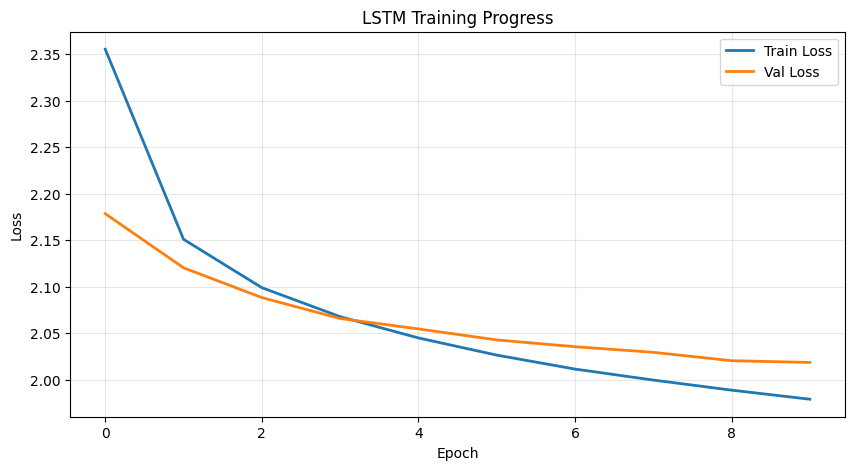

Final train loss: 1.9792
Final val loss: 2.0187


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")

## 10. Visualizing Gate Activations

### Extract Gate Activations for a Sample

Now let's see what the gates are actually doing during inference.

In [18]:
# Get a sample from the validation set
sample_text = full_dataset.get_texts()[len(train_dataset)]  # First validation sample
sample_tokens = tokenizer.encode(sample_text)

print(f"Sample: {sample_text}")
print(f"Tokens: {sample_tokens}")
print(f"Characters: {[tokenizer.chars[t] for t in sample_tokens]}")

# Forward pass with gate tracking
model.eval()
with torch.no_grad():
    x = torch.tensor(sample_tokens, device=device).unsqueeze(0)
    logits, hidden, gates = model(x, return_gates=True)

print(f"\nGate activations extracted!")
print(f"Number of timesteps: {len(gates)}")
print(f"Number of layers: {len(gates[0])}")
print(f"Gate types: {list(gates[0][0].keys())}")

Sample: arib
Tokens: [1, 18, 9, 2]
Characters: ['a', 'r', 'i', 'b']

Gate activations extracted!
Number of timesteps: 4
Number of layers: 1
Gate types: ['forget', 'input', 'output', 'candidate']


### Visualize Gate Activations Over Time

Let's see how each gate behaves as the LSTM processes the sequence.

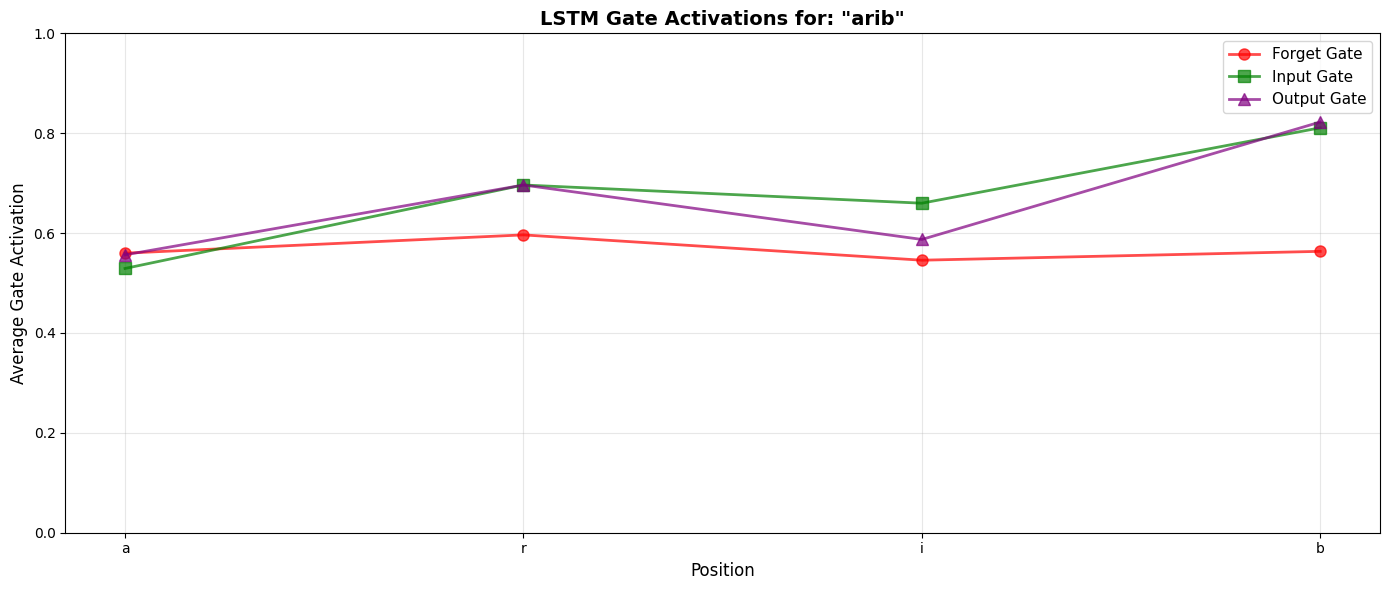

In [19]:
# Extract gate values for first layer, first batch item
layer_idx = 0
batch_idx = 0

forget_vals = [g[layer_idx]['forget'][batch_idx].mean().cpu() for g in gates]
input_vals = [g[layer_idx]['input'][batch_idx].mean().cpu() for g in gates]
output_vals = [g[layer_idx]['output'][batch_idx].mean().cpu() for g in gates]

chars = [tokenizer.chars[t] for t in sample_tokens]
positions = range(len(chars))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(positions, forget_vals, 'o-', label='Forget Gate', linewidth=2, markersize=8, color='red', alpha=0.7)
ax.plot(positions, input_vals, 's-', label='Input Gate', linewidth=2, markersize=8, color='green', alpha=0.7)
ax.plot(positions, output_vals, '^-', label='Output Gate', linewidth=2, markersize=8, color='purple', alpha=0.7)

ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Average Gate Activation', fontsize=12)
ax.set_title(f'LSTM Gate Activations for: "{sample_text}"', fontsize=14, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(chars)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

**Key observations**:
- **Forget gate** (red): Controls what to keep from previous cell state
- **Input gate** (green): Controls how much new information to add
- **Output gate** (purple): Controls what to output

Notice how gates adapt their values based on the input character and context!

### Heatmap of Gate Activations

Let's visualize all hidden dimensions for each gate.

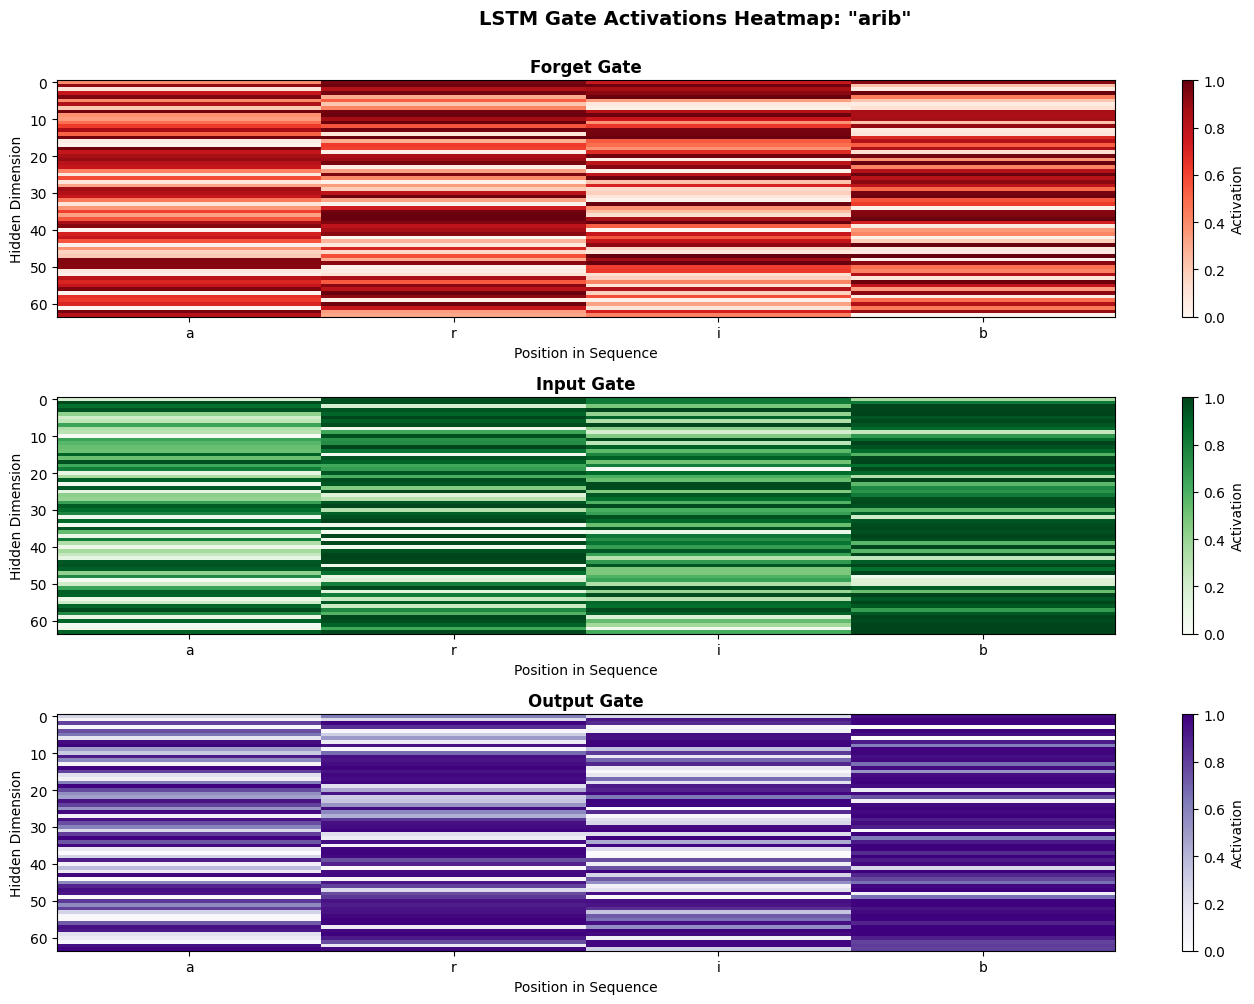

In [20]:
# Extract all dimensions for forget gate
forget_heatmap = torch.stack([g[layer_idx]['forget'][batch_idx] for g in gates]).cpu().numpy()
input_heatmap = torch.stack([g[layer_idx]['input'][batch_idx] for g in gates]).cpu().numpy()
output_heatmap = torch.stack([g[layer_idx]['output'][batch_idx] for g in gates]).cpu().numpy()

# Plot heatmaps
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

gate_data = [
    (forget_heatmap, 'Forget Gate', 'Reds'),
    (input_heatmap, 'Input Gate', 'Greens'),
    (output_heatmap, 'Output Gate', 'Purples')
]

for ax, (data, title, cmap) in zip(axes, gate_data):
    im = ax.imshow(data.T, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    ax.set_xlabel('Position in Sequence')
    ax.set_ylabel('Hidden Dimension')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(chars)
    plt.colorbar(im, ax=ax, label='Activation')

plt.suptitle(f'LSTM Gate Activations Heatmap: "{sample_text}"', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Key insight**: Different hidden dimensions activate differently for different characters. The LSTM learns specialized detectors!

## 11. Generate New Names

### Sample from the Trained Model

Let's generate some new names and see what the LSTM has learned.

In [21]:
print("Generated names (after training):\n")

# Different temperatures
temperatures = [0.5, 0.8, 1.0, 1.2]

for temp in temperatures:
    print(f"Temperature = {temp}:")
    for _ in range(5):
        name = model.generate(tokenizer, temperature=temp, max_length=15)
        print(f"  {name}")
    print()

Generated names (after training):

Temperature = 0.5:
  .makenzie.
  .elianne.
  .katani.
  .calayah.
  .kentrey.

Temperature = 0.8:
  .joshia.
  .tahmari.
  .zirah.
  .gwennie.
  .reyan.

Temperature = 1.0:
  .nakirah.
  .ariah.
  .louel.
  .chring.
  .avrielle.

Temperature = 1.2:
  .lucklail.
  .geaunn.
  .casphner.
  .shrkia.
  .miagan.



**Key observations**:
- **Lower temperature** (0.5): More conservative, common patterns
- **Higher temperature** (1.2): More creative, unusual combinations

The LSTM has learned character-level statistics and name-like patterns!

## 12. Comparing LSTM vs Simple RNN

### Why LSTM is Better: A Direct Comparison

Let's train a simple RNN on the same task to see the difference.

In [22]:
class SimpleRNN(nn.Module):
    """Simple RNN for comparison."""
    
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, _ = self.rnn(embedded)
        logits = self.fc(rnn_out)
        return logits
    
    def generate(self, tokenizer, start_tokens=None, max_length=20, temperature=1.0):
        self.eval()
        with torch.no_grad():
            if start_tokens is None:
                tokens = [tokenizer.encode(".")[0]]
            else:
                tokens = start_tokens.copy()
            
            for _ in range(max_length):
                x = torch.tensor([tokens], device=next(self.parameters()).device)
                logits = self(x)
                logits = logits[0, -1] / temperature
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1).item()
                tokens.append(next_token)
                if next_token == tokenizer.encode(".")[0]:
                    break
            
            return tokenizer.decode(tokens)

# Create and train RNN
rnn_model = SimpleRNN(vocab_size, embed_size, hidden_size).to(device)
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)

print(f"Simple RNN created!")
print(f"Parameters: {count_parameters(rnn_model):,}")
print(f"\nTraining RNN for comparison...\n")

rnn_history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    # Training
    rnn_model.train()
    total_loss = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x, y = x.to(device), y.to(device)
        logits = rnn_model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        rnn_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), max_norm=1.0)
        rnn_optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    # Validation
    rnn_model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = rnn_model(x)
            loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
            total_loss += loss.item()
    
    val_loss = total_loss / len(val_loader)
    rnn_history['train_loss'].append(train_loss)
    rnn_history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\nRNN training complete!")

Simple RNN created!
Parameters: 8,891

Training RNN for comparison...



Epoch 1:   0%|          | 0/226 [00:00<?, ?it/s]

Epoch 1:   9%|▉         | 20/226 [00:00<00:01, 197.41it/s]

Epoch 1:  25%|██▍       | 56/226 [00:00<00:00, 288.96it/s]

Epoch 1:  41%|████      | 92/226 [00:00<00:00, 320.70it/s]

...

Epoch 10:  33%|███▎      | 75/226 [00:00<00:00, 374.30it/s]

Epoch 10:  50%|█████     | 113/226 [00:00<00:00, 375.15it/s]

Epoch 10:  67%|██████▋   | 151/226 [00:00<00:00, 373.21it/s]

Epoch 10:  84%|████████▎ | 189/226 [00:00<00:00, 373.80it/s]

Epoch 10/10 - Train Loss: 2.0634, Val Loss: 2.0691

RNN training complete!


### Compare Training Curves

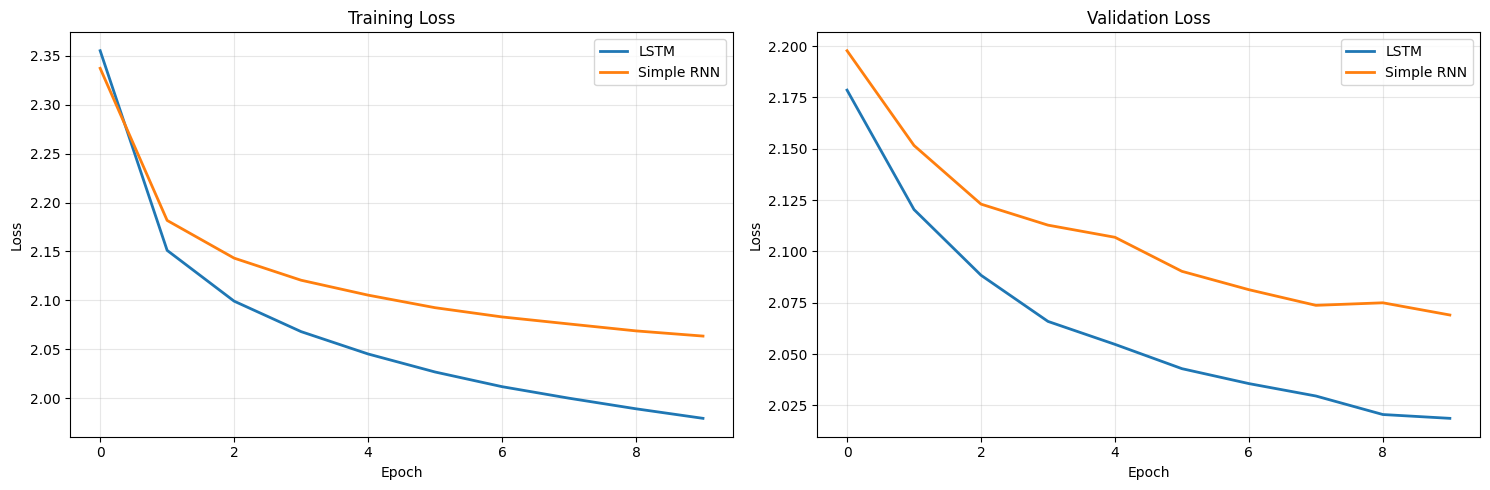

Final LSTM val loss: 2.0187
Final RNN val loss:  2.0691

LSTM improvement: 0.0503


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
axes[0].plot(history['train_loss'], label='LSTM', linewidth=2)
axes[0].plot(rnn_history['train_loss'], label='Simple RNN', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(history['val_loss'], label='LSTM', linewidth=2)
axes[1].plot(rnn_history['val_loss'], label='Simple RNN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final LSTM val loss: {history['val_loss'][-1]:.4f}")
print(f"Final RNN val loss:  {rnn_history['val_loss'][-1]:.4f}")
print(f"\nLSTM improvement: {(rnn_history['val_loss'][-1] - history['val_loss'][-1]):.4f}")

### Compare Generations

In [24]:
print("Comparison: LSTM vs Simple RNN\n")
print("="*50)

for i in range(10):
    lstm_name = model.generate(tokenizer, temperature=0.8)
    rnn_name = rnn_model.generate(tokenizer, temperature=0.8)
    print(f"LSTM: {lstm_name:20s}  |  RNN: {rnn_name}")

Comparison: LSTM vs Simple RNN

LSTM: .jonas.               |  RNN: .cayza.
LSTM: .avia.                |  RNN: .alexson.
LSTM: .liliase.             |  RNN: .adilani.
LSTM: .emmiana.             |  RNN: .mitiel.
LSTM: .paran.               |  RNN: .nelleigh.
LSTM: .jayleth.             |  RNN: .borandi.
LSTM: .alivanya.            |  RNN: .zamyr.
LSTM: .natalia.             |  RNN: .etania.
LSTM: .abdudiel.            |  RNN: .pairo.
LSTM: .kayliah.             |  RNN: .ashin.


**Key insight**: LSTMs typically produce more coherent, name-like outputs because they better capture long-range dependencies!

## 13. Key Takeaways

### What We Learned About LSTMs

**1. The Problem:**
- Vanilla RNNs suffer from vanishing gradients
- Can't learn dependencies beyond ~10 time steps
- Gradients decay exponentially during backpropagation

**2. The Solution - Gates:**
- **Forget gate**: Controls what to remove from memory (0 = forget, 1 = keep)
- **Input gate**: Controls what new information to add (0 = ignore, 1 = add)
- **Output gate**: Controls what to expose as output (0 = hide, 1 = show)

**3. Two States:**
- **Cell state** ($c_t$): Long-term memory, flows with minimal transformation
- **Hidden state** ($h_t$): Short-term output, filtered version of cell state

**4. Why Gradients Flow Better:**
- Cell state updated via addition (not multiplication)
- Gates use element-wise operations
- Gradient highway allows information to flow unchanged

**5. Practical Tips:**
- Always clip gradients when training RNNs
- LSTMs work well for sequences with long-range dependencies
- More parameters than vanilla RNN, but worth it

**6. Gate Behavior:**
- Gates learn to specialize for different patterns
- Different hidden dimensions activate for different inputs
- Visualization helps understand what the network learned

### When to Use LSTMs:
- ✅ Sequences with long-term dependencies (text, speech, time series)
- ✅ When you need to remember information from far back
- ✅ Character/word-level language modeling
- ✅ Machine translation, speech recognition

### Modern Alternatives:
- **GRUs**: Simpler variant with fewer gates (faster, similar performance)
- **Transformers**: Attention-based, now dominant for NLP (but need more data)
- **State Space Models**: Recent innovation combining RNN efficiency with Transformer quality

### The Big Picture:
LSTMs solved a fundamental problem in deep learning and enabled the modern NLP revolution. While Transformers have largely replaced them in NLP, LSTMs remain important for:
- Understanding recurrent architectures
- Time series with limited data
- Real-time streaming applications
- Edge devices (smaller models)